# Phase 2 - Analyse Manuelle 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from sqlalchemy import create_engine

pd.set_option('display.max_columns', None)

db_host = os.getenv("DB_HOST", "postgres")
engine = create_engine(f"postgresql://postgres:postgres@{db_host}:5432/games_db")

df = pd.read_sql("SELECT * FROM games_brut", engine)
print(f"Dataset: {len(df):,} rows x {len(df.columns)} columns")

Dataset: 122,611 rows x 40 columns


## 1. Complétude
#### Analyse des valeurs manquantes

In [2]:
# Taux de valeurs manquantes par colonne
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print(missing_df[missing_df['missing_pct'] > 0])

                missing_count  missing_pct
movies                 122611       100.00
score_rank             122571        99.97
metacritic_url         118355        96.53
reviews                110541        90.16
notes                  100153        81.68
website                 72935        59.48
support_url             68469        55.84
tags                    39265        32.02
support_email           22263        18.16
categories               8953         7.30
publishers               8909         7.27
about_the_game           8449         6.89
developers               8437         6.88
genres                   8413         6.86
screenshots              6018         4.91
header_image               81         0.07


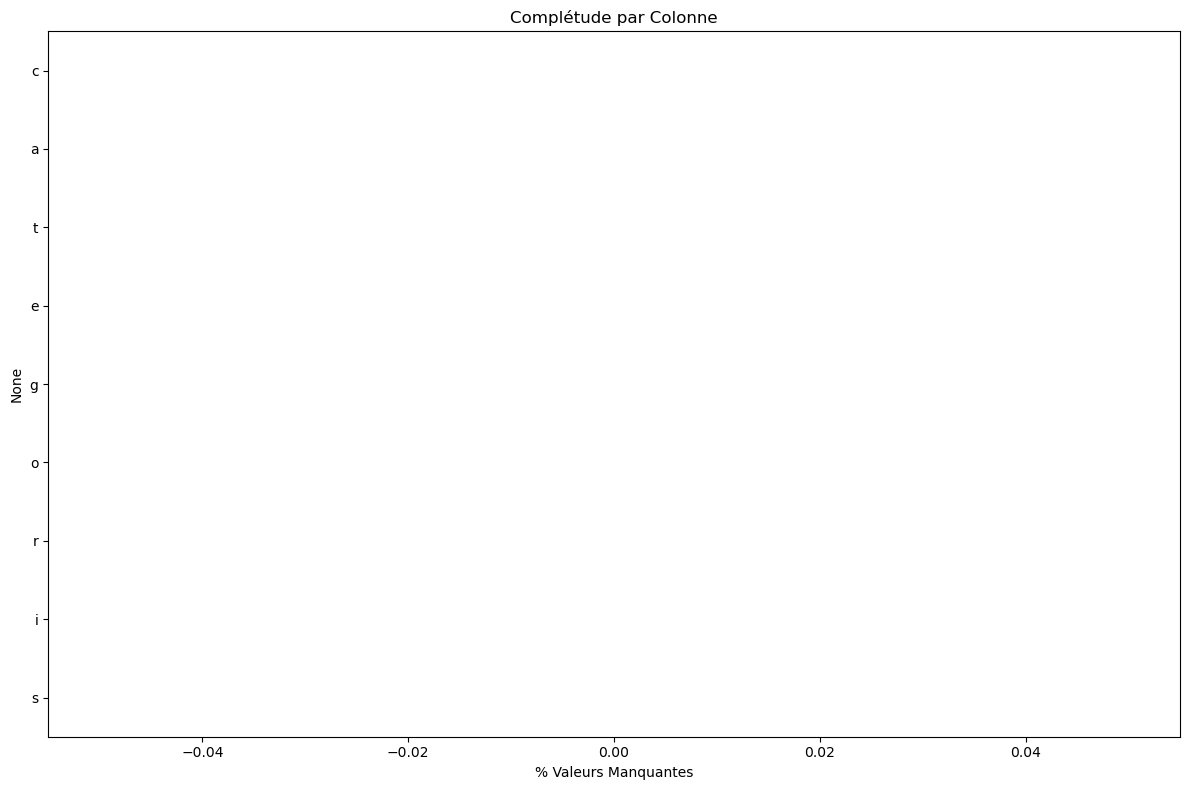

Colonnes à supprimer (>95% null): ['movies', 'score_rank', 'metacritic_url']


In [3]:
# Visualisation des valeurs manquantes
fig, ax = plt.subplots(figsize=(12, 8))
cols_with_missing = missing_df[missing_df['missing_pct'] > 0].index
sns.barplot(x=missing_df.loc[cols_with_missing, 'missing_pct'],
            y=cols_with_missing, hue=cols_with_missing, ax=ax, palette='Reds_r', legend=False)
ax.set_xlabel('% Valeurs Manquantes')
ax.set_title('Complétude par Colonne')
plt.tight_layout()
plt.show()

# Colonnes à supprimer (>95% manquant)
cols_to_drop = missing_df[missing_df['missing_pct'] > 95].index.tolist()
print(f"Colonnes à supprimer (>95% null): {cols_to_drop}")

## 2. Unicité
#### Détection des doublons

In [4]:
# Doublons sur la clé primaire (app_id)
duplicates_appid = df[df.duplicated(subset=['app_id'], keep=False)]
print(f"Doublons sur app_id: {len(duplicates_appid)} lignes")

# Doublons sur le nom du jeu
duplicates_name = df[df.duplicated(subset=['name'], keep=False)].sort_values('name')
print(f"Doublons sur name: {len(duplicates_name)} lignes ({duplicates_name['name'].nunique()} noms uniques)")

if len(duplicates_name) > 0:
    print("\nExemples de noms dupliqués:")
    display(duplicates_name[['app_id', 'name', 'release_date', 'price']].head(20))

# Doublons complets (toutes colonnes identiques)
full_duplicates = df[df.duplicated(keep=False)]
print(f"\nDoublons complets: {len(full_duplicates)} lignes")

Doublons sur app_id: 0 lignes
Doublons sur name: 2115 lignes (959 noms uniques)

Exemples de noms dupliqués:


,app_id,name,release_date,price
30162,3022780,A Better Tomorrow,2024-07-31,0.00
108093,3763930,A Better Tomorrow,2025-09-30,0.00
53275,557900,A Walk in the Woods,2020-04-21,0.00
62631,842420,A Walk in the Woods,2018-05-01,0.00
17281,1544540,ALONE,2021-05-31,0.74
100268,1826070,ALONE,2021-12-23,8.99
23384,1768480,ASTRA,2021-10-12,0.89
87721,2691830,ASTRA,2024-01-05,2.99
121849,1522190,ASTRA,2021-02-26,0.00
87550,2058460,Absence of Light,2024-01-22,7.49



Doublons complets: 0 lignes


## 3. Exactitude
#### Validation des formats

In [5]:
# Validation des emails
email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
emails = df['support_email'].dropna()
invalid_emails = emails[~emails.str.match(email_pattern, na=False)]

print(f"Emails totaux: {len(emails)}")
print(f"Emails invalides: {len(invalid_emails)} ({len(invalid_emails)/len(emails)*100:.1f}%)")
print("\nExemples d'emails invalides:")
print(invalid_emails.head(10).tolist())

# Validation des URLs
url_pattern = r'^https?://[\w\-]+(\.[\w\-]+)+'
for col in ['website', 'support_url']:
    urls = df[col].dropna()
    if len(urls) > 0:
        invalid_urls = urls[~urls.str.match(url_pattern, na=False)]
        print(f"\n{col}: {len(invalid_urls)} URLs invalides sur {len(urls)} ({len(invalid_urls)/len(urls)*100:.1f}%)")

# Validation des prix
invalid_prices = df[df['price'] < 0]
print(f"\nPrix négatifs: {len(invalid_prices)}")
high_prices = df[df['price'] > 500]
print(f"Prix > 500$: {len(high_prices)}")
if len(high_prices) > 0:
    display(high_prices[['name', 'price']].head(10))

Emails totaux: 100348
Emails invalides: 769 (0.8%)

Exemples d'emails invalides:
['https://helpdesk.aerosoft.com/portal/home', 'https://sites.google.com/view/lonelygamedev/join?authuser=0', 'support@wbgames.com or Wbgames.intsupport@warnerbros.com', 'https://1030807747@qq.com', 'https://g4feedback@gmail.com', 'https://www.heiwa-ent.com/%E3%81%8A%E5%95%8F%E5%90%88%E3%82%8F%E3%81%9B/', 'outbreakzombie.co', 'preppypenguingamesgmail.com', 'http://www.iobit.com/en/onlinefeedback.php', 'http://www.cyberlink.com/support/contact-support.jsp']

website: 50 URLs invalides sur 49676 (0.1%)

support_url: 4333 URLs invalides sur 54142 (8.0%)

Prix négatifs: 0
Prix > 500$: 3


,name,price
34536,Ascent Free-Roaming VR Experience,999.00
41116,The Leverage Game Business Edition,999.98
68326,The Leverage Game,999.98


## 4. Validité
#### Conformité aux règles métier

In [6]:
# Required age: doit être >= 0
print("Distribution de required_age:")
print(df['required_age'].value_counts().head(10))
invalid_ages = df[(df['required_age'] < 0) | (df['required_age'] > 21)]
print(f"\nÂges invalides (<0 ou >21): {len(invalid_ages)}")

# Metacritic score: doit être entre 0 et 100
invalid_metacritic = df[(df['metacritic_score'] < 0) | (df['metacritic_score'] > 100)]
print(f"\nMetacritic scores hors plage [0-100]: {len(invalid_metacritic)}")
print(f"Distribution Metacritic (non-zéro):")
print(df[df['metacritic_score'] > 0]['metacritic_score'].describe())

# Discount: doit être entre 0 et 100
invalid_discount = df[(df['discount'] < 0) | (df['discount'] > 100)]
print(f"\nDiscounts hors plage [0-100]: {len(invalid_discount)}")

Distribution de required_age:
required_age
0     121339
17       828
13       175
18       164
16        32
10        26
12        23
3          6
7          5
6          4
Name: count, dtype: int64

Âges invalides (<0 ou >21): 0

Metacritic scores hors plage [0-100]: 0
Distribution Metacritic (non-zéro):
count    4256.000000
mean       73.893327
std        10.264373
min         6.000000
25%        68.000000
50%        76.000000
75%        81.000000
max        97.000000
Name: metacritic_score, dtype: float64

Discounts hors plage [0-100]: 0


## 5. Cohérence
#### Règles inter-colonnes

In [7]:
# Cohérence: Metacritic score > 0 mais pas de Metacritic url
has_score = df['metacritic_score'] > 0
has_url = df['metacritic_url'].notna()
inconsistent_metacritic = df[has_score & ~has_url]
print(f"Jeux avec Metacritic score mais sans URL: {len(inconsistent_metacritic)}")

inconsistent_metacritic2 = df[~has_score & has_url]
print(f"Jeux avec Metacritic URL mais score = 0: {len(inconsistent_metacritic2)}")

# Cohérence: Playtime median > Playtime average (anormal)
inconsistent_playtime = df[df['median_playtime_forever'] > df['average_playtime_forever'] * 2]
print(f"\nJeux où median playtime > 2x average: {len(inconsistent_playtime)}")

# Cohérence: Prix > 0 mais jeu gratuit (Free to Play dans Tags)
free_tags = df['tags'].fillna('').str.contains('Free to Play', case=False)
has_price = df['price'] > 0.0
inconsistent_free = df[free_tags & has_price]
print(f"\nJeux 'Free to Play' avec prix > 0: {len(inconsistent_free)}")
if len(inconsistent_free) > 0:
    display(inconsistent_free[['name', 'price', 'app_id']].head(5))

Jeux avec Metacritic score mais sans URL: 0
Jeux avec Metacritic URL mais score = 0: 0

Jeux où median playtime > 2x average: 0

Jeux 'Free to Play' avec prix > 0: 319


,name,price,app_id
990,Company of Heroes 2 - Ardennes Assault,4.99,317850
1201,Classic Card Games 3D,12.99,941920
1210,Vertical Drop Heroes HD,1.74,311480
1529,Cyber Car,9.99,1966870
2151,Pentasma,0.74,1217350


## 6. Actualité
#### Données obsolètes ou futures

Jeux avec date de sortie future: 0

Jeux sortis avant 2000: 5

Distribution par année (dernières 15):
release_year
2012      322
2013      467
2014     1523
2015     2515
2016     4141
2017     5920
2018     7461
2019     7242
2020     8804
2021    11067
2022    12284
2023    14596
2024    20031
2025    24973
2026       84
Name: count, dtype: int64


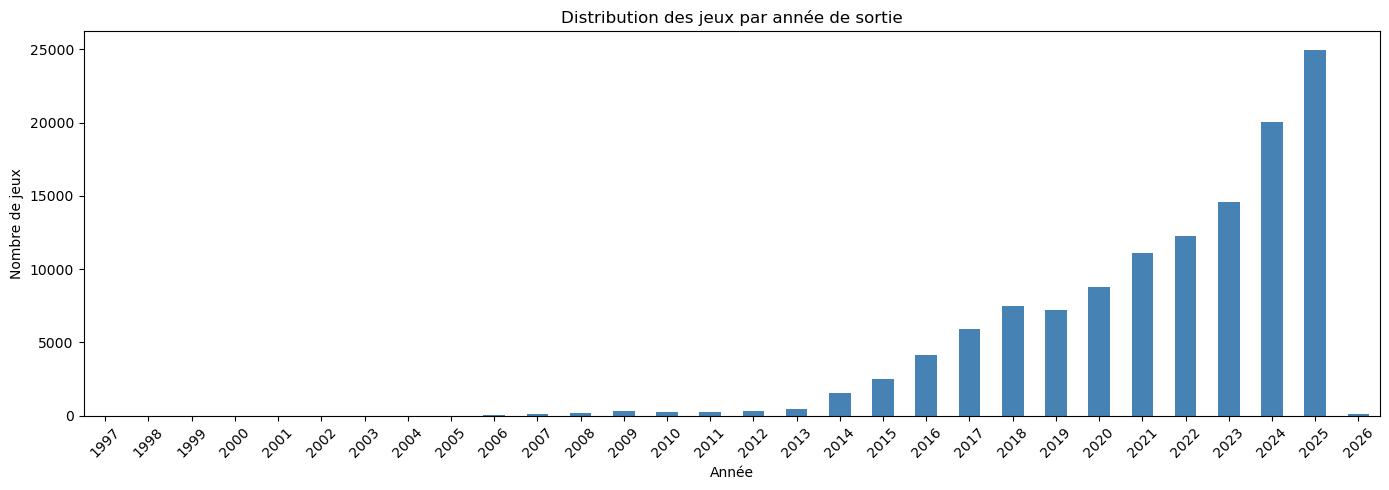

In [8]:
# Dates futures (erreurs)
today = pd.Timestamp.now()
future_dates = df[df['release_date'] > today]
print(f"Jeux avec date de sortie future: {len(future_dates)}")
if len(future_dates) > 0:
    display(future_dates[['name', 'release_date']].head(10))

# Dates très anciennes
old_games = df[df['release_date'] < '2000-01-01']
print(f"\nJeux sortis avant 2000: {len(old_games)}")

# Distribution par année
df['release_year'] = df['release_date'].dt.year
print("\nDistribution par année (dernières 15):")
print(df['release_year'].value_counts().sort_index().tail(15))

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
df['release_year'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de jeux')
ax.set_title('Distribution des jeux par année de sortie')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Outliers
#### Détection des valeurs aberrantes

Outliers par colonne (méthode IQR)
price: 9297 outliers (7.6%)
peak_ccu: 19676 outliers (16.0%)
dlc_count: 17771 outliers (14.5%)
metacritic_score: 4256 outliers (3.5%)
positive: 20797 outliers (17.0%)
negative: 20696 outliers (16.9%)
achievements: 8433 outliers (6.9%)
recommendations: 20906 outliers (17.1%)
average_playtime_forever: 26119 outliers (21.3%)


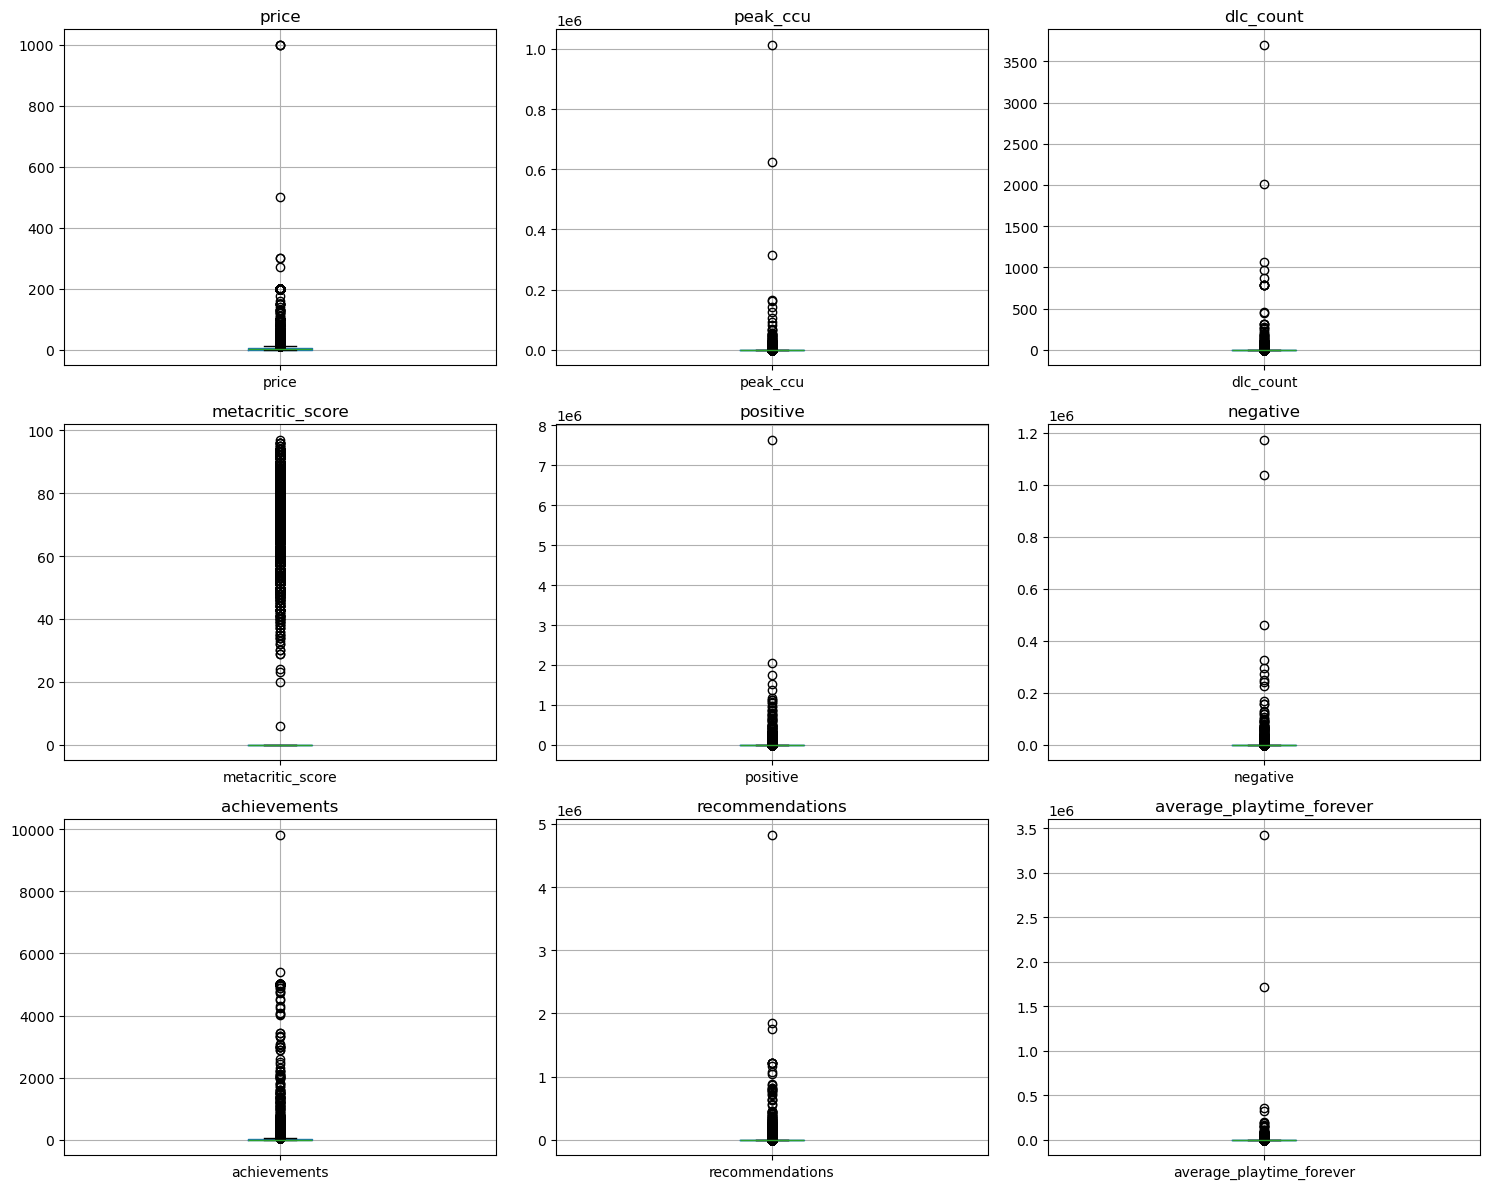

In [9]:
# Colonnes numériques à analyser
numeric_cols = ['price', 'peak_ccu', 'dlc_count', 'metacritic_score',
                'positive', 'negative', 'achievements', 'recommendations',
                'average_playtime_forever']

def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

sum_outliers = 0
print("Outliers par colonne (méthode IQR)")
for col in numeric_cols:
    outliers = detect_outliers_iqr(df[col])
    sum_outliers += outliers.sum()
    print(f"{col}: {outliers.sum()} outliers ({outliers.sum()/len(df)*100:.1f}%)")

# Boxplots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), numeric_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Synthèse des anomalies

In [10]:
# Score de qualité global
total_cells = df.shape[0] * df.shape[1]
null_cells = df.isnull().sum().sum()
completeness_score = (1 - null_cells / total_cells) * 100

print("Résumé de la qualité des données - STEAM GAMES DATASET")
print(f"\nDataset: {len(df):,} lignes x {len(df.columns)} colonnes")
print(f"\nScores :")
print(f"   Complétude globale: {completeness_score:.1f}%")
print(f"\nAnomalies détectées:")
print(f"   - Colonnes >95% null: {len(cols_to_drop)}")
print(f"   - Doublons sur name: {len(duplicates_name)}")
print(f"   - Emails invalides: {len(invalid_emails)}")
print(f"   - Dates futures: {len(future_dates)}")
print(f"   - Valeurs aberrantes: {sum_outliers} (sur 9 colonnes quantitatives)")

Résumé de la qualité des données - STEAM GAMES DATASET

Dataset: 122,611 lignes x 41 colonnes

Scores :
   Complétude globale: 83.6%

Anomalies détectées:
   - Colonnes >95% null: 3
   - Doublons sur name: 2115
   - Emails invalides: 769
   - Dates futures: 0
   - Valeurs aberrantes: 147951 (sur 9 colonnes quantitatives)
